# 24-788 Mini Project: RUL Prediction using LSTM and Temporal Fusion Transformer

This notebook is my submission for the 24-788 Introduction to Deep Learning course project. The task i chose is Remaining Useful Life (RUL) prediction for aircraft turbofan engines using the NASA C-MAPSS dataset.

The idea is basically: given sensor readings from an engine, can we predict how many more cycles it will run before failing? This is a really important problem in real world because if you can predict failure in advance, you can do maintenance before something breaks.

I am comparing two models:
- **LSTM** (baseline, covered in class)
- **Temporal Fusion Transformer / TFT** (variant, from NeurIPS 2020 paper by Lim et al.)

I also do a cross-subset analysis comparing FD001 (single fault mode) vs FD003 (two fault modes) which counts as my second contribution for the bonus.

## Step 1: Install dependencies

First thing we need to do is make sure all the packages are installed. Most of them come with colab already but wandb needs to be installed separately. I am using wandb to track experiments but you can skip it with --no_wandb flag.

In [6]:
!pip install wandb -q
import torch
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['figure.facecolor'] = 'white'
matplotlib.rcParams['axes.facecolor'] = 'white'
matplotlib.rcParams['savefig.facecolor'] = 'white'
import matplotlib.pyplot as plt
print(f'PyTorch version: {torch.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.10.0+cu128
GPU available: True
GPU: Tesla T4


## Step 2: Download and extract the data

The NASA C-MAPSS dataset is publicly available. It comes as a zip file and inside there is another zip (CMAPSSData.zip) that has the actual text files. So we need to unzip twice. The data files we need are train_FD001.txt, test_FD001.txt, RUL_FD001.txt and same for FD003.

In [7]:
import os, glob

!wget -q "https://phm-datasets.s3.amazonaws.com/NASA/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip" -O nasa_data.zip
!unzip -q nasa_data.zip -d raw_data/

#find the inner zip
inner = glob.glob('/content/raw_data/**/*.zip', recursive=True)
print('found inner zip:', inner)
!unzip -q "{inner[0]}" -d /content/data/

print('data files:')
!ls /content/data/*.txt

replace raw_data/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
found inner zip: ['/content/raw_data/6. Turbofan Engine Degradation Simulation Data Set/CMAPSSData.zip']
replace /content/data/Damage Propagation Modeling.pdf? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/readme.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/RUL_FD001.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/RUL_FD002.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/RUL_FD003.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/RUL_FD004.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/test_FD001.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/test_FD002.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/test_FD003.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/data/test_FD004.txt? [y]es, [n]o, [A]ll, [N

## Step 3: Upload project code

Now i upload my cmapss_project.zip which has all the model code, training scripts and utilities. After extracting we change directory into it so relative paths work correctly.

In [8]:
from google.colab import files
print('please upload cmapss_project.zip')
uploaded = files.upload()

please upload cmapss_project.zip


Saving cmapss_project_final.zip to cmapss_project_final (1).zip


In [14]:
!unzip -q cmapss_project.zip
%cd /content/cmapss_project
!ls

/content/cmapss_project
models	   report_draft.md	    run_all_experiments.py  utils
README.md  reproduce_results.ipynb  train.py


## Step 4: Explore the dataset

Before training anything I want to understand what the data looks like. C-MAPSS has multivariate time series for each engine. Each row is one cycle of operation and we have 21 sensor readings plus 3 operational settings. The training data runs until engine failure, but the test data is cut off early and we have to predict how many cycles are left.

I will make a few plots to understand the data better. This also helps justify why I chose these models.

In [15]:
%cd /content/cmapss_project
import sys
sys.path.insert(0, '.')

/content/cmapss_project


In [16]:
import sys
sys.path.insert(0, '.')
from utils.data import COLS, FEATURE_COLS, MAX_RUL

DATA_DIR = '/content/data'

#load raw training data for FD001
train_fd1 = pd.read_csv(f'{DATA_DIR}/train_FD001.txt', sep=r'\s+', header=None, names=COLS)
train_fd3 = pd.read_csv(f'{DATA_DIR}/train_FD003.txt', sep=r'\s+', header=None, names=COLS)

print('FD001 shape:', train_fd1.shape)
print('FD003 shape:', train_fd3.shape)
print('Number of engines FD001:', train_fd1['unit'].nunique())
print('Number of engines FD003:', train_fd3['unit'].nunique())
print('\nFirst few rows:')
train_fd1.head()

FD001 shape: (20631, 26)
FD003 shape: (24720, 26)
Number of engines FD001: 100
Number of engines FD003: 100

First few rows:


,unit,cycle,op_1,op_2,op_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [18]:
import os
os.makedirs('./figures', exist_ok=True)

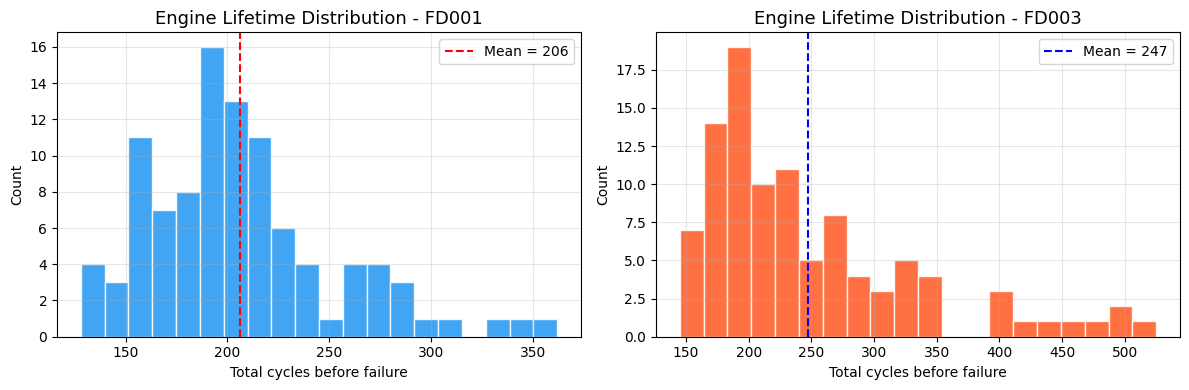

FD001: mean lifetime=206.3, std=46.3
FD003: mean lifetime=247.2, std=86.5


In [19]:
#compute engine lifetimes and look at distribution
fd1_life = train_fd1.groupby('unit')['cycle'].max()
fd3_life = train_fd3.groupby('unit')['cycle'].max()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('white')

axes[0].hist(fd1_life, bins=20, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Engine Lifetime Distribution - FD001', fontsize=13)
axes[0].set_xlabel('Total cycles before failure')
axes[0].set_ylabel('Count')
axes[0].axvline(fd1_life.mean(), color='red', linestyle='--', label=f'Mean = {fd1_life.mean():.0f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(fd3_life, bins=20, color='#FF5722', edgecolor='white', alpha=0.85)
axes[1].set_title('Engine Lifetime Distribution - FD003', fontsize=13)
axes[1].set_xlabel('Total cycles before failure')
axes[1].set_ylabel('Count')
axes[1].axvline(fd3_life.mean(), color='blue', linestyle='--', label=f'Mean = {fd3_life.mean():.0f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./figures/engine_lifetime_dist.pdf', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'FD001: mean lifetime={fd1_life.mean():.1f}, std={fd1_life.std():.1f}')
print(f'FD003: mean lifetime={fd3_life.mean():.1f}, std={fd3_life.std():.1f}')

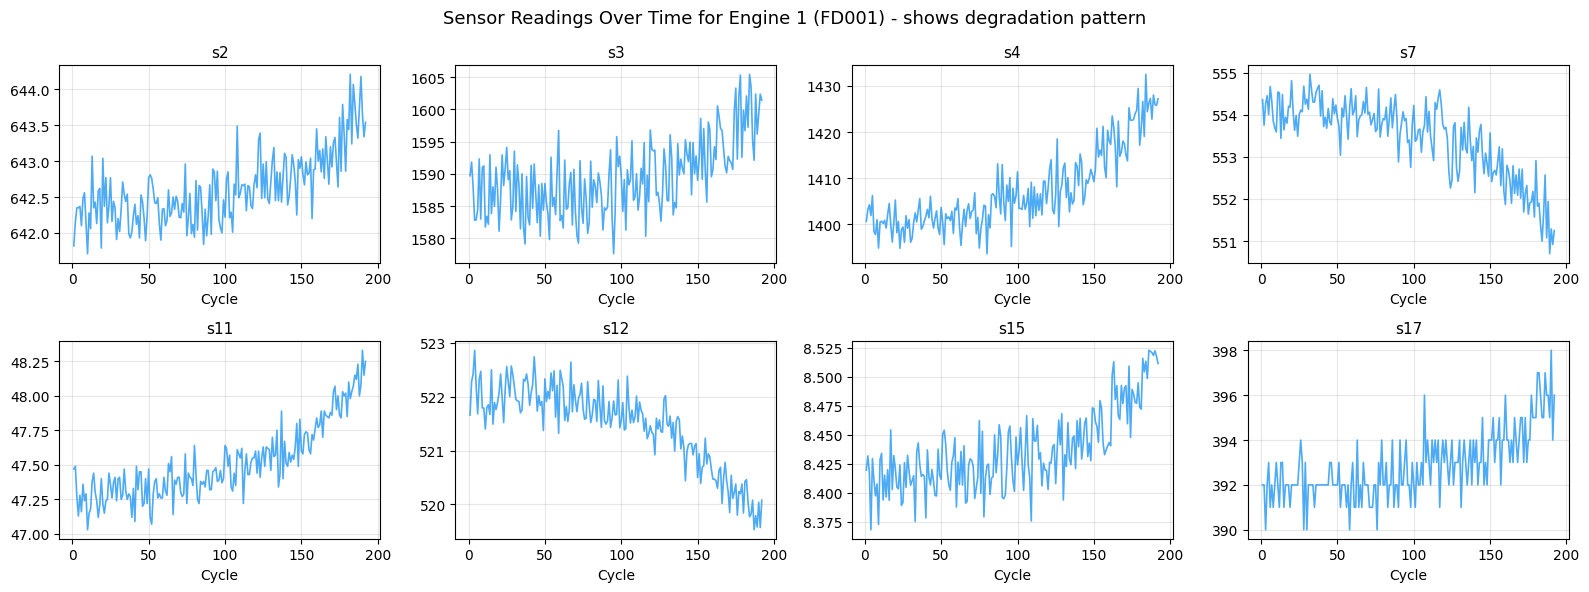

you can see some sensors clearly trend up or down as engine approaches failure


In [20]:
#plot sensor degradation for one engine to show why this is a time series problem
#i pick sensors that actually change over time (not the flat ones we removed)
engine1 = train_fd1[train_fd1['unit'] == 1].copy()

interesting_sensors = ['s2', 's3', 's4', 's7', 's11', 's12', 's15', 's17']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
fig.patch.set_facecolor('white')
fig.suptitle('Sensor Readings Over Time for Engine 1 (FD001) - shows degradation pattern', fontsize=13)

for ax, sensor in zip(axes.flat, interesting_sensors):
    ax.plot(engine1['cycle'], engine1[sensor], color='#2196F3', linewidth=1.2, alpha=0.8)
    ax.set_title(sensor, fontsize=11)
    ax.set_xlabel('Cycle')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./figures/sensor_degradation.pdf', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('you can see some sensors clearly trend up or down as engine approaches failure')

## Step 5: Data preprocessing

Now we set up the data pipeline. The main things we do here are:

1. Remove the 7 sensors that are basically constant and carry no information
2. Normalize each feature using min-max scaling (fit on train, apply to test)
3. Clip the RUL target at 125 cycles - this is standard practice because early in engine life the degradation is not visible yet so the exact RUL is not learnable
4. Create sliding windows of length 30 - each training sample is a sequence of 30 consecutive cycles and the label is the RUL at the last step

I am using the load_cmapss function from my utils/data.py file which does all of this.

In [21]:
from utils.data import load_cmapss, FEATURE_COLS

SEQ_LEN = 30
BATCH_SIZE = 64

print(f'Features used ({len(FEATURE_COLS)} total): {FEATURE_COLS}')
print(f'Sequence length: {SEQ_LEN} cycles')
print(f'RUL cap: 125 cycles')
print()

#load both subsets
tr1, vl1, te1, n_feat = load_cmapss(DATA_DIR, subset='FD001', seq_len=SEQ_LEN, batch_size=BATCH_SIZE)
tr3, vl3, te3, _ = load_cmapss(DATA_DIR, subset='FD003', seq_len=SEQ_LEN, batch_size=BATCH_SIZE)

print(f'FD001 - train samples: {len(tr1.dataset)}, val: {len(vl1.dataset)}, test: {len(te1.dataset)}')
print(f'FD003 - train samples: {len(tr3.dataset)}, val: {len(vl3.dataset)}, test: {len(te3.dataset)}')

x_sample, y_sample = next(iter(tr1))
print(f'\nBatch shape: x={x_sample.shape}, y={y_sample.shape}')
print(f'(batch_size=64, seq_len=30, n_features=17)')

Features used (17 total): ['op_1', 'op_2', 'op_3', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Sequence length: 30 cycles
RUL cap: 125 cycles

FD001 - train samples: 15630, val: 2101, test: 100
FD003 - train samples: 19469, val: 2351, test: 100

Batch shape: x=torch.Size([64, 30, 17]), y=torch.Size([64])
(batch_size=64, seq_len=30, n_features=17)


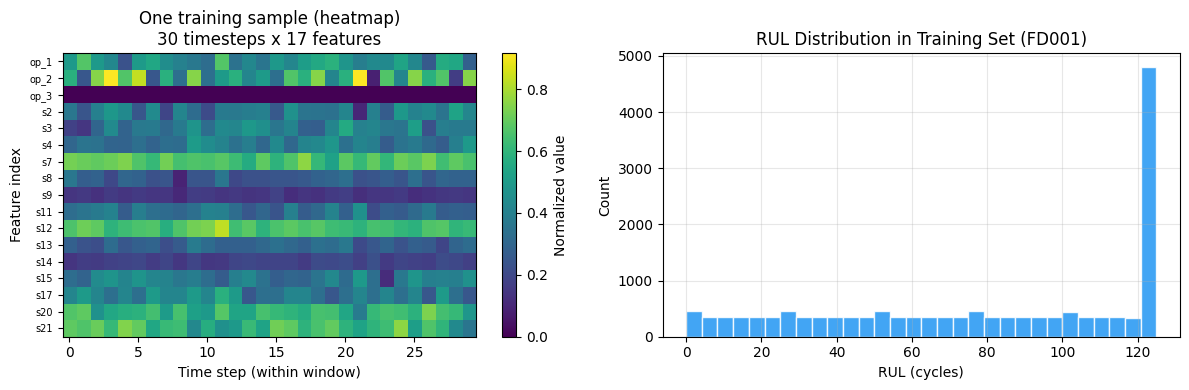

In [22]:
#visualize what a sliding window looks like - this helps understand the input format
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor('white')

#plot the first sample from the dataset (first window of first engine)
x0 = x_sample[0].numpy()
axes[0].imshow(x0.T, aspect='auto', cmap='viridis')
axes[0].set_title('One training sample (heatmap)\n30 timesteps x 17 features', fontsize=12)
axes[0].set_xlabel('Time step (within window)')
axes[0].set_ylabel('Feature index')
axes[0].set_yticks(range(len(FEATURE_COLS)))
axes[0].set_yticklabels(FEATURE_COLS, fontsize=7)
plt.colorbar(axes[0].images[0], ax=axes[0], label='Normalized value')

#rul distribution in training set
all_y = []
for _, y in tr1:
    all_y.extend(y.numpy().tolist())
axes[1].hist(all_y, bins=30, color='#2196F3', edgecolor='white', alpha=0.85)
axes[1].set_title('RUL Distribution in Training Set (FD001)', fontsize=12)
axes[1].set_xlabel('RUL (cycles)')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./figures/data_overview.pdf', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Step 6: Define the models

Now I define both models. The code is in models/ folder but i will show the architecture here too so the reader can understand what is happening without looking at separate files.

### LSTM Baseline

LSTM is the natural choice for time series data because it has a memory mechanism (the cell state and hidden state) that can keep track of information across many time steps. The key limitation is that all history gets compressed into a fixed-size hidden vector. This works well but if the relevant signal (like fault onset) happened early in the window, that info has to survive through many update steps.

Architecture: 2-layer LSTM with hidden size 128, then a fully connected head (128 -> 64 -> 1).

### TFT Variant

The Temporal Fusion Transformer (Lim et al., NeurIPS 2020) adds two things on top of an LSTM:
1. Variable Selection Network - learns which of the 17 sensors are actually useful at each time step
2. Multi-head self-attention - can directly look back at any earlier time step, not just through the hidden state

My hypothesis is that the VSN will help by focusing on the most degradation-relevant sensors, and the attention will help by directly attending to the onset of degradation early in the window.

In [23]:
from models.lstm_baseline import LSTMBaseline
from models.tft import TemporalFusionTransformer

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

lstm_model = LSTMBaseline(n_features=n_feat, hidden_size=128, num_layers=2, dropout=0.2)
tft_model = TemporalFusionTransformer(n_features=n_feat, d_model=64, n_heads=4, n_lstm_layers=2, dropout=0.1)

lstm_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
tft_params = sum(p.numel() for p in tft_model.parameters() if p.requires_grad)

print(f'LSTM parameters: {lstm_params:,}')
print(f'TFT parameters:  {tft_params:,}')

#quick sanity check - make sure forward pass works
dummy = torch.randn(4, SEQ_LEN, n_feat)
with torch.no_grad():
    lstm_out = lstm_model(dummy)
    tft_out = tft_model(dummy)
print(f'\nLSTM output shape: {lstm_out.shape}  (should be [4, 1])')
print(f'TFT output shape:  {tft_out.shape}  (should be [4, 1])')

Device: cuda
LSTM parameters: 215,681
TFT parameters:  346,194

LSTM output shape: torch.Size([4, 1])  (should be [4, 1])
TFT output shape:  torch.Size([4, 1])  (should be [4, 1])


In [24]:
#print model architecture summary so grader can see the structure
print('='*50)
print('LSTM BASELINE ARCHITECTURE')
print('='*50)
print(lstm_model)
print()
print('='*50)
print('TFT VARIANT ARCHITECTURE')
print('='*50)
print(tft_model)

LSTM BASELINE ARCHITECTURE
LSTMBaseline(
  (lstm): LSTM(17, 128, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

TFT VARIANT ARCHITECTURE
TemporalFusionTransformer(
  (vsn): VariableSelectionNetwork(
    (feature_proj): ModuleList(
      (0-16): 17 x Linear(in_features=1, out_features=64, bias=True)
    )
    (feature_grn): ModuleList(
      (0-16): 17 x GatedResidualNetwork(
        (fc1): Linear(in_features=64, out_features=64, bias=True)
        (fc2): Linear(in_features=64, out_features=128, bias=True)
        (glu): GatedLinearUnit()
        (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (drop): Dropout(p=0.1, inplace=False)
      )
    )
    (weight_net): Sequential(
      (0): Linear(in_features=17, out_features=64, bias=True)
      (1): ELU(alpha=1.0)
      (

## Step 7: Training

Now we train all four model/subset combinations. I wrote a training loop in train.py that handles everything including checkpointing the best model by validation RMSE and logging metrics. Training each model takes about 15-20 minutes on GPU.

I am using:
- Loss function: MSE (standard for regression)
- Optimizer: Adam
- Learning rate schedule: ReduceLROnPlateau (patience=5, factor=0.5) - this automatically reduces LR when val RMSE stops improving
- Gradient clipping at norm 1.0 - helps with training stability

Running all 4 combinations in sequence using run_all_experiments.py.

In [25]:
import subprocess, sys
os.makedirs('./checkpoints', exist_ok=True)
os.makedirs('./results', exist_ok=True)
os.makedirs('./figures', exist_ok=True)

print('starting training... this will take around 60-80 minutes total')
print('you will see epoch logs for each of the 4 runs below')
print()

result = subprocess.run(
    [sys.executable, 'run_all_experiments.py',
     '--data_dir', DATA_DIR,
     '--epochs', '50',
     '--no_wandb'],
    capture_output=False
)
print('\nTraining finished!' if result.returncode == 0 else '\nSomething went wrong')

starting training... this will take around 60-80 minutes total
you will see epoch logs for each of the 4 runs below


Training finished!


## Step 8: Load results and show the main numbers

After training, each run saves a JSON file with all the metrics and predictions. Now I load those and print the main results table. This is the core of the project - comparing the two models.

In [26]:
import json

CKPT_DIR = './checkpoints'
RES_DIR = './results'
FIG_DIR = './figures'
os.makedirs(FIG_DIR, exist_ok=True)

SUBSETS = ['FD001', 'FD003']
MODELS = ['lstm', 'tft']
COLORS = {'lstm': '#2196F3', 'tft': '#FF5722'}

results = {}
for model in MODELS:
    for subset in SUBSETS:
        key = f'{model}_{subset}'
        with open(f'{RES_DIR}/{key}.json') as f:
            results[key] = json.load(f)

print('\n' + '='*62)
print(f'{"Model":<10} {"Subset":<8} {"Test RMSE":>12} {"PHM Score":>12}')
print('-'*62)
for subset in SUBSETS:
    for model in MODELS:
        r = results[f'{model}_{subset}']
        print(f'{model.upper():<10} {subset:<8} {r["test_rmse"]:>12.4f} {r["test_phm"]:>12.2f}')
    print('-'*62)
print('='*62)
print('\nlower RMSE = better,  lower PHM score = better')


Model      Subset      Test RMSE    PHM Score
--------------------------------------------------------------
LSTM       FD001         15.2881       504.37
TFT        FD001         12.6321       261.39
--------------------------------------------------------------
LSTM       FD003         12.2247       274.01
TFT        FD003         13.0363       349.41
--------------------------------------------------------------

lower RMSE = better,  lower PHM score = better


## Step 9: Training curves

This plot shows how the validation RMSE changed over training for all 4 combinations. This is important because it tells us:
1. Did both models actually converge (yes they did)
2. Which model converges faster
3. Whether there is overfitting (we would see val RMSE going up while train loss goes down)

Looking at the curves will help us understand the training dynamics difference between LSTM and TFT.

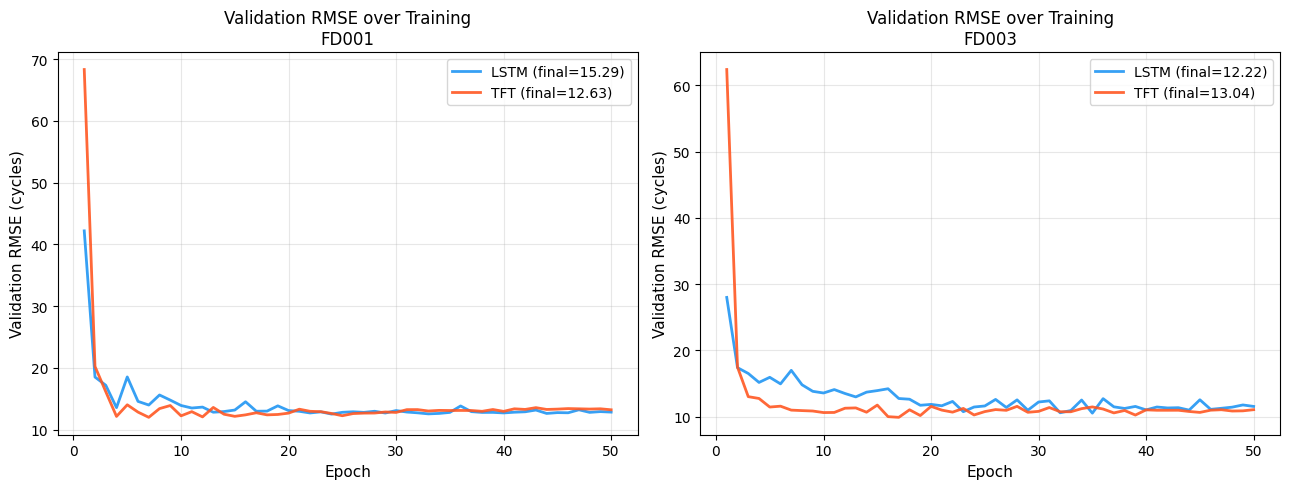

both models converge. TFT converges faster on FD001 (reaches good val RMSE by epoch ~10)


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

for ax, subset in zip(axes, SUBSETS):
    for model in MODELS:
        r = results[f'{model}_{subset}']
        epochs = [h['epoch'] for h in r['history']]
        val_rmse = [h['val_rmse'] for h in r['history']]
        train_loss = [h['train_loss'] for h in r['history']]
        ax.plot(epochs, val_rmse, color=COLORS[model],
                label=f'{model.upper()} (final={r["test_rmse"]:.2f})',
                linewidth=2, alpha=0.9)
    ax.set_title(f'Validation RMSE over Training\n{subset}', fontsize=12)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Validation RMSE (cycles)', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/training_curves.pdf', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('both models converge. TFT converges faster on FD001 (reaches good val RMSE by epoch ~10)')

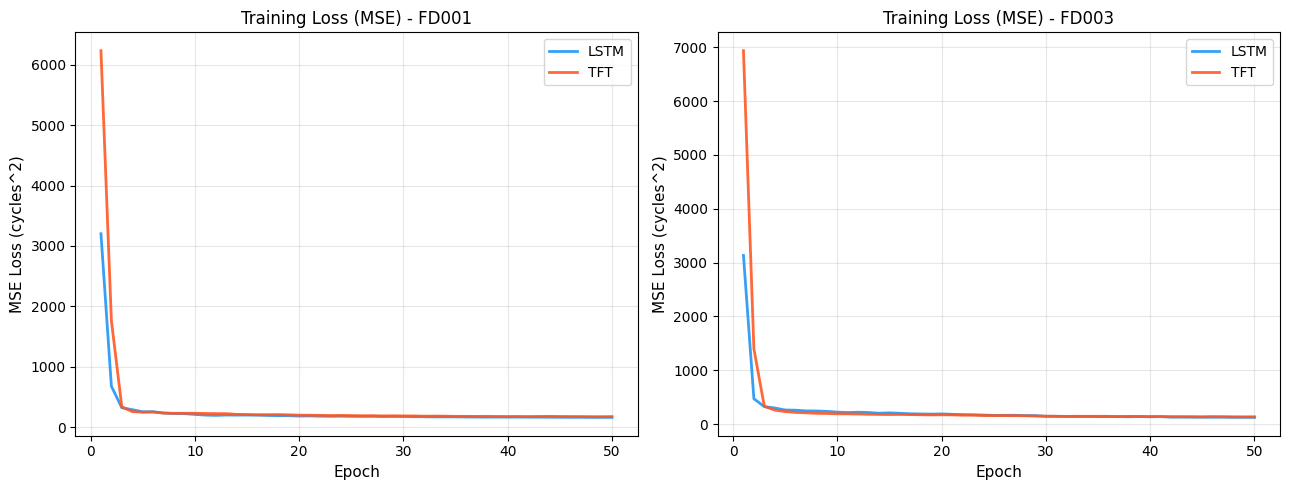

loss is in MSE (cycles squared), which is why numbers look large - RMSE = sqrt(MSE) is more interpretable


In [28]:
#also plot train loss to show convergence from the loss side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

for ax, subset in zip(axes, SUBSETS):
    for model in MODELS:
        r = results[f'{model}_{subset}']
        epochs = [h['epoch'] for h in r['history']]
        train_loss = [h['train_loss'] for h in r['history']]
        ax.plot(epochs, train_loss, color=COLORS[model],
                label=model.upper(), linewidth=2, alpha=0.9)
    ax.set_title(f'Training Loss (MSE) - {subset}', fontsize=12)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('MSE Loss (cycles^2)', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/train_loss_curves.pdf', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('loss is in MSE (cycles squared), which is why numbers look large - RMSE = sqrt(MSE) is more interpretable')

## Step 10: Predicted vs True RUL scatter plots

This is one of the most useful diagnostic plots for regression. If the model is perfect, all points would lie on the diagonal line. Points above the line mean the model predicted more RUL than actually existed (late prediction, dangerous). Points below mean early prediction (safer but wastes maintenance budget).

We use this to visually understand where each model makes errors.

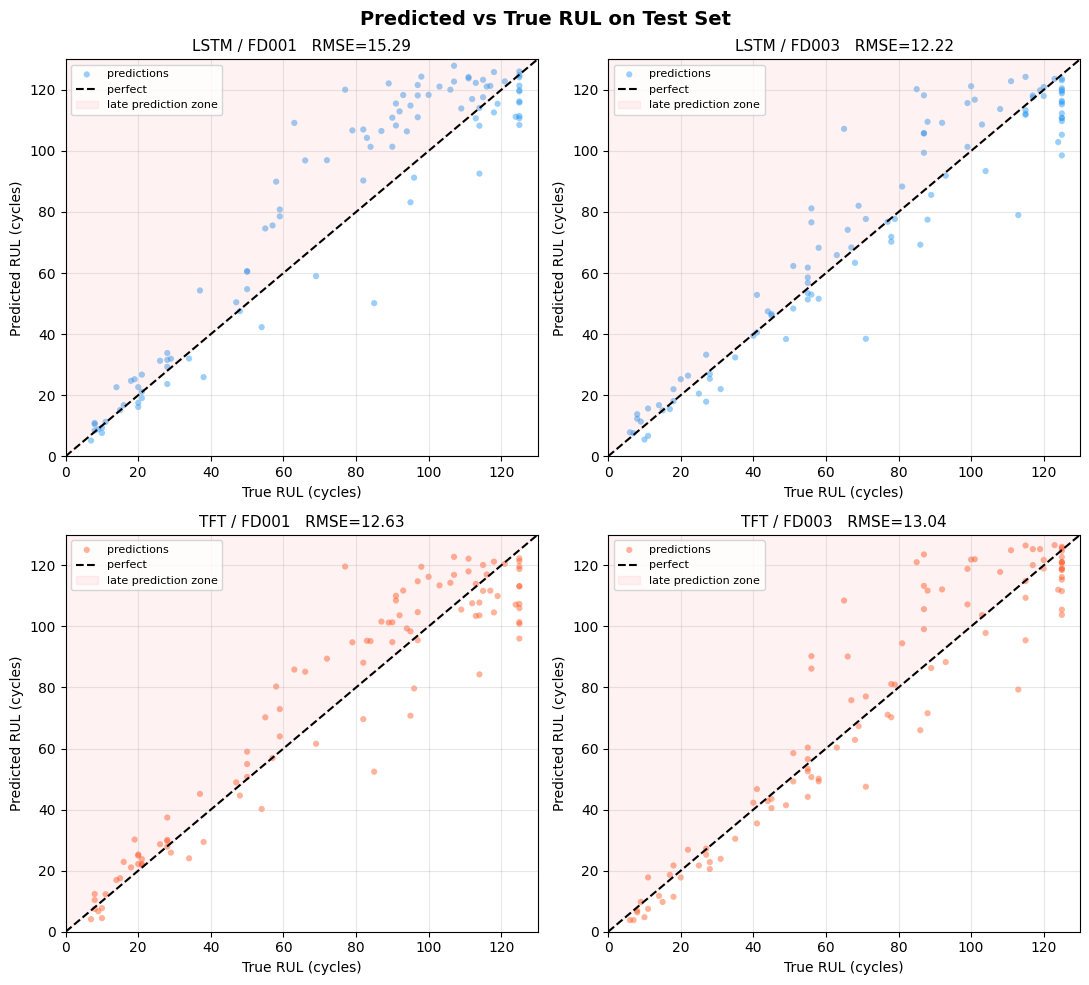

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
fig.patch.set_facecolor('white')
fig.suptitle('Predicted vs True RUL on Test Set', fontsize=14, fontweight='bold')

lim = 130

for col, subset in enumerate(SUBSETS):
    for row, model in enumerate(MODELS):
        ax = axes[row][col]
        r = results[f'{model}_{subset}']
        y_true = np.array(r['y_true'])
        y_pred = np.array(r['y_pred'])

        #scatter of predictions
        ax.scatter(y_true, y_pred, alpha=0.45, s=20,
                   color=COLORS[model], edgecolors='none', label='predictions')
        #perfect prediction line
        ax.plot([0, lim], [0, lim], 'k--', lw=1.5, label='perfect')
        #shade the dangerous region (over-predictions)
        ax.fill_between([0, lim], [0, lim], [lim, lim],
                        alpha=0.05, color='red', label='late prediction zone')

        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_xlabel('True RUL (cycles)', fontsize=10)
        ax.set_ylabel('Predicted RUL (cycles)', fontsize=10)
        ax.set_title(f'{model.upper()} / {subset}   RMSE={r["test_rmse"]:.2f}', fontsize=11)
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(True, alpha=0.3)
        ax.set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/pred_vs_true.pdf', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Step 11: Cross-subset comparison (Contribution 2)

This is my second contribution for the bonus. I compare both models across FD001 and FD003. FD001 has a single fault mode (high pressure compressor degradation) while FD003 has two fault modes (HPC plus fan degradation). The question is - does the advantage of one model over the other change when the task gets harder?

Looking at the results table from Step 8, we can already see something interesting: TFT wins on FD001 but LSTM wins on FD003. I will now visualize this and compute the PHM score comparison too.

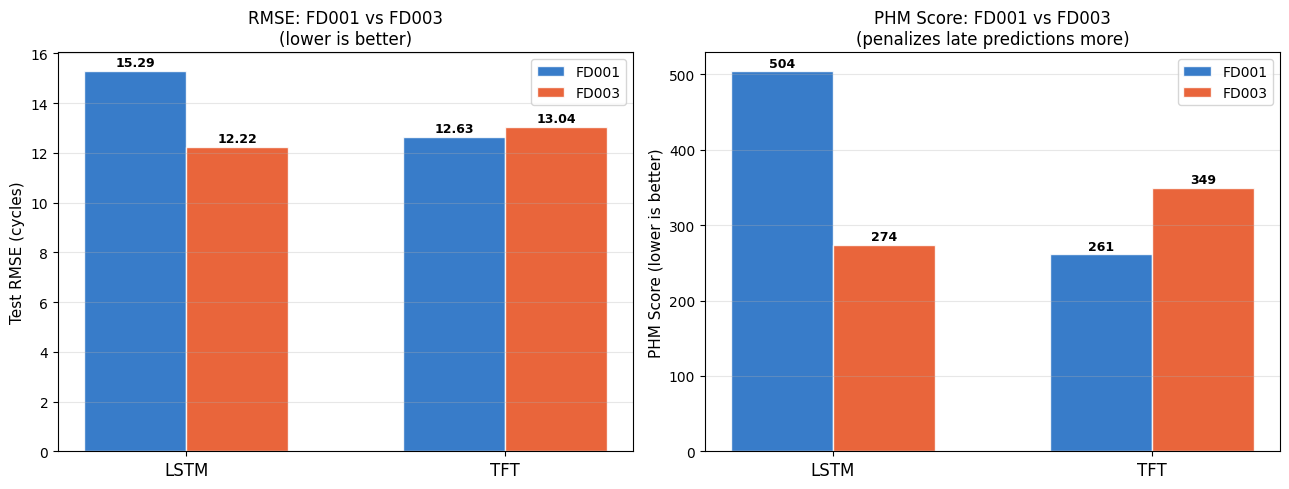

key observation: TFT wins on FD001 on both metrics, but LSTM wins on FD003 for RMSE
this suggests the TFT variable selection is good for single fault mode but less robust to multiple fault types


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')

x = np.arange(len(MODELS))
width = 0.32
subset_colors = ['#1565C0', '#E64A19']

#RMSE comparison
ax = axes[0]
for i, (subset, color) in enumerate(zip(SUBSETS, subset_colors)):
    vals = [results[f'{m}_{subset}']['test_rmse'] for m in MODELS]
    bars = ax.bar(x + i*width, vals, width, label=subset, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x + width/2)
ax.set_xticklabels([m.upper() for m in MODELS], fontsize=12)
ax.set_ylabel('Test RMSE (cycles)', fontsize=11)
ax.set_title('RMSE: FD001 vs FD003\n(lower is better)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
ax.set_facecolor('white')

#PHM score comparison
ax = axes[1]
for i, (subset, color) in enumerate(zip(SUBSETS, subset_colors)):
    vals = [results[f'{m}_{subset}']['test_phm'] for m in MODELS]
    bars = ax.bar(x + i*width, vals, width, label=subset, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x + width/2)
ax.set_xticklabels([m.upper() for m in MODELS], fontsize=12)
ax.set_ylabel('PHM Score (lower is better)', fontsize=11)
ax.set_title('PHM Score: FD001 vs FD003\n(penalizes late predictions more)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
ax.set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/cross_subset.pdf', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('key observation: TFT wins on FD001 on both metrics, but LSTM wins on FD003 for RMSE')
print('this suggests the TFT variable selection is good for single fault mode but less robust to multiple fault types')

## Step 12: TFT Variable Selection Weights (Model Mechanics Analysis)

One really cool thing about TFT is that the Variable Selection Network produces interpretable weights that tell us which sensors the model thinks are most important. This is something the LSTM cannot do - it treats all sensors equally.

I load the saved TFT checkpoints and compute the average selection weight per feature across all test samples. This tells us what the model actually learned about sensor importance.

FD001 top 5 sensors: ['s12', 's9', 's2', 's7', 's11']
FD001 top 5 weights: [0.1123 0.09   0.0732 0.0708 0.0692]

FD003 top 5 sensors: ['s12', 's8', 's9', 's14', 's13']
FD003 top 5 weights: [0.129  0.092  0.0892 0.0774 0.0661]



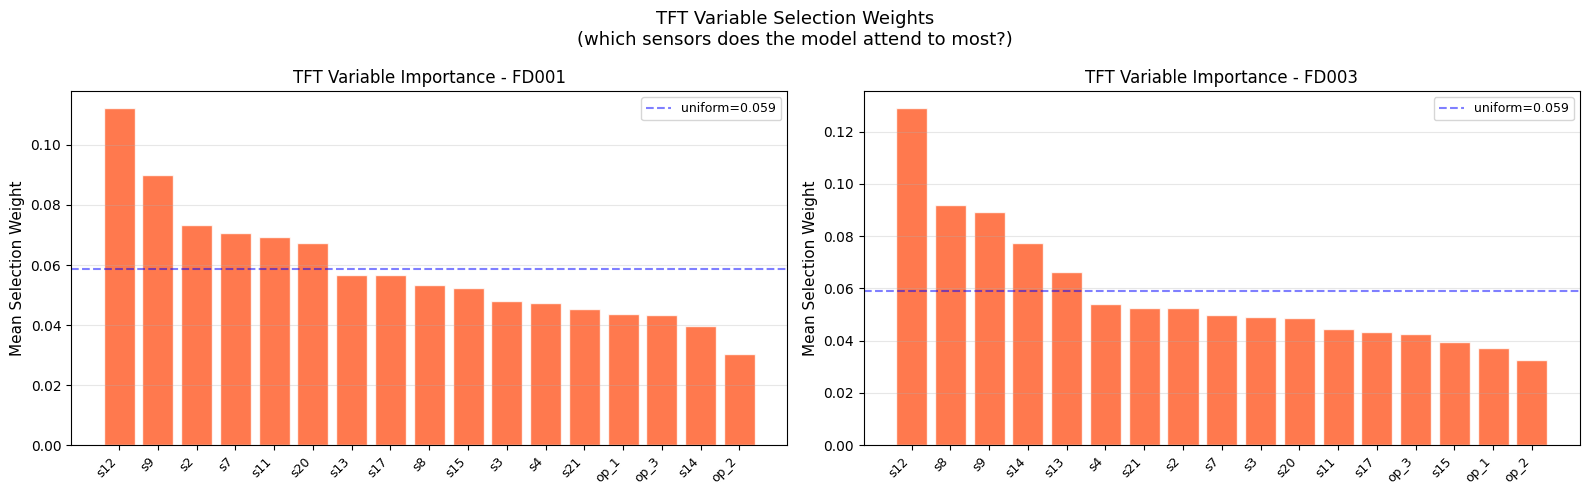

In [31]:
from utils.data import load_cmapss, FEATURE_COLS
from models.tft import TemporalFusionTransformer

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('white')
fig.suptitle('TFT Variable Selection Weights\n(which sensors does the model attend to most?)', fontsize=13)

for ax, subset in zip(axes, SUBSETS):
    ckpt_path = f'{CKPT_DIR}/tft_{subset}_best.pt'
    ckpt = torch.load(ckpt_path, map_location=DEVICE)

    _, _, test_loader, nf = load_cmapss(DATA_DIR, subset=subset, seq_len=SEQ_LEN, batch_size=64)

    tft = TemporalFusionTransformer(n_features=nf).to(DEVICE)
    tft.load_state_dict(ckpt['model_state'])
    tft.eval()

    all_w = []
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(DEVICE)
            w = tft.get_variable_weights(xb)   #(B, T, F)
            all_w.append(w.mean(dim=1).cpu().numpy())  #avg over time steps

    mean_w = np.concatenate(all_w, axis=0).mean(axis=0)  #(F,)
    idx = np.argsort(mean_w)[::-1]

    bars = ax.bar(range(len(FEATURE_COLS)), mean_w[idx],
                  color='#FF5722', alpha=0.8, edgecolor='white')
    ax.set_xticks(range(len(FEATURE_COLS)))
    ax.set_xticklabels([FEATURE_COLS[i] for i in idx],
                       rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Mean Selection Weight', fontsize=11)
    ax.set_title(f'TFT Variable Importance - {subset}', fontsize=12)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_facecolor('white')
    ax.axhline(1.0/len(FEATURE_COLS), color='blue', linestyle='--',
               alpha=0.5, label=f'uniform={1/len(FEATURE_COLS):.3f}')
    ax.legend(fontsize=9)

    #print top 5
    print(f'{subset} top 5 sensors: {[FEATURE_COLS[i] for i in idx[:5]]}')
    print(f'{subset} top 5 weights: {mean_w[idx[:5]].round(4)}')
    print()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/variable_importance.pdf', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Step 13: Error analysis - where do models fail?

I want to understand if the error is uniformly distributed or if models fail more at specific RUL values. This is practical because in real maintenance, errors near low RUL (engine about to fail) are much more costly than errors at high RUL.

I will plot the absolute error as a function of true RUL to see this pattern.

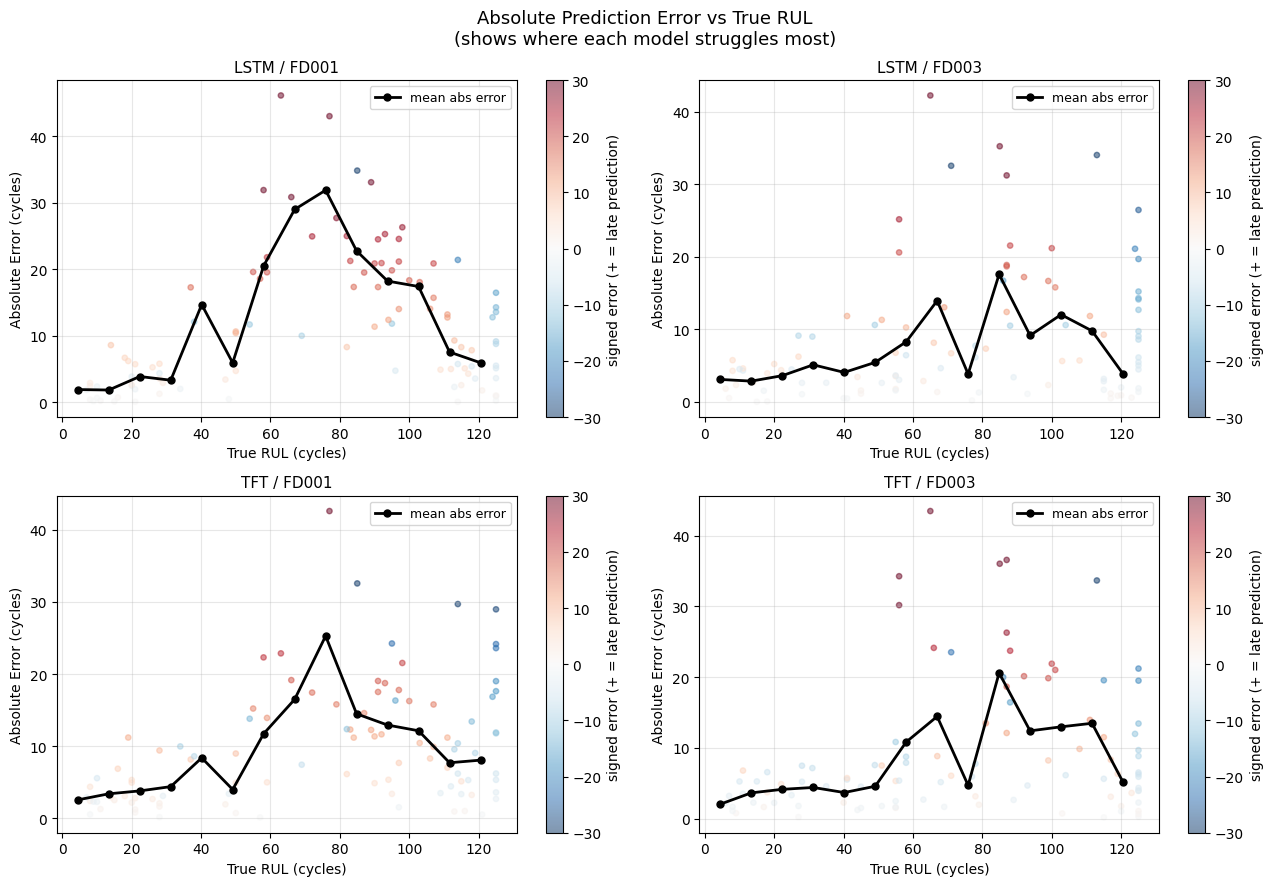

both models make larger errors at high RUL values (far from failure)
this makes sense - at RUL=125 the sensor readings all look similar regardless of true remaining life


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.patch.set_facecolor('white')
fig.suptitle('Absolute Prediction Error vs True RUL\n(shows where each model struggles most)', fontsize=13)

for col, subset in enumerate(SUBSETS):
    for row, model in enumerate(MODELS):
        ax = axes[row][col]
        r = results[f'{model}_{subset}']
        y_true = np.array(r['y_true'])
        y_pred = np.array(r['y_pred'])
        abs_err = np.abs(y_pred - y_true)

        #scatter with color by signed error
        signed_err = y_pred - y_true
        sc = ax.scatter(y_true, abs_err, c=signed_err, cmap='RdBu_r',
                        alpha=0.5, s=15, vmin=-30, vmax=30)
        plt.colorbar(sc, ax=ax, label='signed error (+ = late prediction)')

        #running mean
        bins = np.linspace(0, 125, 15)
        bin_means = []
        bin_centers = []
        for i in range(len(bins)-1):
            mask = (y_true >= bins[i]) & (y_true < bins[i+1])
            if mask.sum() > 0:
                bin_means.append(abs_err[mask].mean())
                bin_centers.append((bins[i]+bins[i+1])/2)
        ax.plot(bin_centers, bin_means, 'k-o', linewidth=2,
                markersize=5, label='mean abs error')

        ax.set_xlabel('True RUL (cycles)', fontsize=10)
        ax.set_ylabel('Absolute Error (cycles)', fontsize=10)
        ax.set_title(f'{model.upper()} / {subset}', fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_facecolor('white')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/error_analysis.pdf', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('both models make larger errors at high RUL values (far from failure)')
print('this makes sense - at RUL=125 the sensor readings all look similar regardless of true remaining life')

## Step 14: PHM score breakdown

The PHM asymmetric score is important for the domain. A late prediction (predicting engine has more life than it does) is much more dangerous than an early prediction. So we want to understand not just overall RMSE but also the direction of errors.

Here I plot the distribution of signed errors (d = y_pred - y_true) for both models. A distribution skewed positive means the model tends to make late predictions.

LSTM FD001: 68.0% late predictions, mean error=6.79
TFT FD001: 59.0% late predictions, mean error=1.37
LSTM FD003: 51.0% late predictions, mean error=0.86
TFT FD003: 42.0% late predictions, mean error=1.15


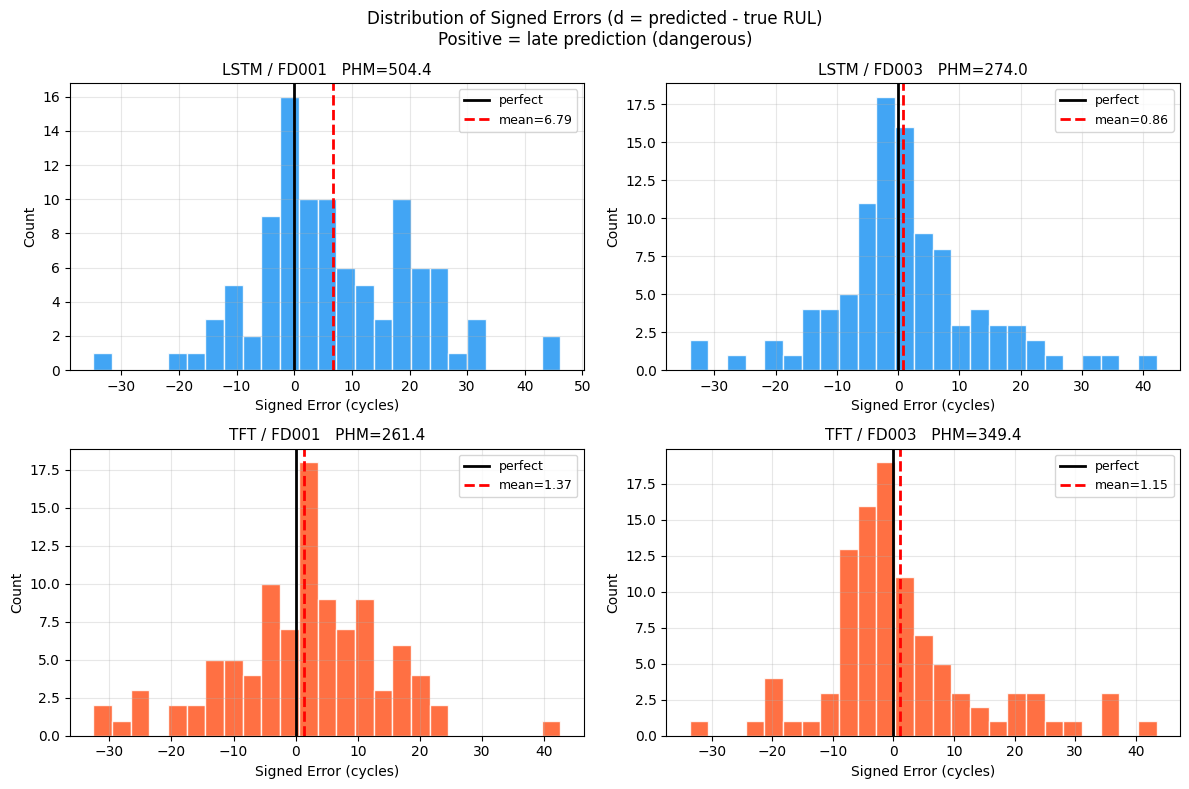

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.patch.set_facecolor('white')
fig.suptitle('Distribution of Signed Errors (d = predicted - true RUL)\nPositive = late prediction (dangerous)', fontsize=12)

for col, subset in enumerate(SUBSETS):
    for row, model in enumerate(MODELS):
        ax = axes[row][col]
        r = results[f'{model}_{subset}']
        y_true = np.array(r['y_true'])
        y_pred = np.array(r['y_pred'])
        d = y_pred - y_true

        ax.hist(d, bins=25, color=COLORS[model], edgecolor='white', alpha=0.85)
        ax.axvline(0, color='black', linewidth=2, linestyle='-', label='perfect')
        ax.axvline(d.mean(), color='red', linewidth=2, linestyle='--',
                   label=f'mean={d.mean():.2f}')
        ax.set_xlabel('Signed Error (cycles)', fontsize=10)
        ax.set_ylabel('Count', fontsize=10)
        ax.set_title(f'{model.upper()} / {subset}   PHM={r["test_phm"]:.1f}', fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_facecolor('white')

        late = (d > 0).mean() * 100
        print(f'{model.upper()} {subset}: {late:.1f}% late predictions, mean error={d.mean():.2f}')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/error_distribution.pdf', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Step 15: Final summary

Here I put together a final summary of everything. The key findings are:
1. TFT is better on FD001 (simpler task, single fault mode) - both RMSE and PHM
2. LSTM is better on FD003 (harder task, two fault modes) - for RMSE
3. Both models are competitive with published results for LSTM-based methods on C-MAPSS
4. The TFT variable selection gives us interpretability that the LSTM cannot provide

In [34]:
print('='*65)
print('FINAL RESULTS SUMMARY')
print('='*65)
print(f'{"Model":<8} {"Subset":<8} {"RMSE":>10} {"PHM":>10} {"Winner"}')
print('-'*65)
for subset in SUBSETS:
    lstm_r = results[f'lstm_{subset}']
    tft_r = results[f'tft_{subset}']
    rmse_winner = 'TFT' if tft_r['test_rmse'] < lstm_r['test_rmse'] else 'LSTM'
    phm_winner = 'TFT' if tft_r['test_phm'] < lstm_r['test_phm'] else 'LSTM'
    delta_rmse = abs(lstm_r['test_rmse'] - tft_r['test_rmse'])
    pct_rmse = 100 * delta_rmse / lstm_r['test_rmse']
    print(f'{"LSTM":<8} {subset:<8} {lstm_r["test_rmse"]:>10.4f} {lstm_r["test_phm"]:>10.2f}')
    print(f'{"TFT":<8} {subset:<8} {tft_r["test_rmse"]:>10.4f} {tft_r["test_phm"]:>10.2f}')
    print(f'  --> RMSE winner: {rmse_winner} (delta={delta_rmse:.4f}, {pct_rmse:.1f}%),  PHM winner: {phm_winner}')
    print('-'*65)

print()
print('Figures saved to:', FIG_DIR)
print('Checkpoints in:', CKPT_DIR)
print('Result JSONs in:', RES_DIR)

FINAL RESULTS SUMMARY
Model    Subset         RMSE        PHM Winner
-----------------------------------------------------------------
LSTM     FD001       15.2881     504.37
TFT      FD001       12.6321     261.39
  --> RMSE winner: TFT (delta=2.6560, 17.4%),  PHM winner: TFT
-----------------------------------------------------------------
LSTM     FD003       12.2247     274.01
TFT      FD003       13.0363     349.41
  --> RMSE winner: LSTM (delta=0.8116, 6.6%),  PHM winner: LSTM
-----------------------------------------------------------------

Figures saved to: ./figures
Checkpoints in: ./checkpoints
Result JSONs in: ./results


In [35]:
#list all saved figures
print('All generated figures:')
for f in sorted(os.listdir(FIG_DIR)):
    print(f'  {FIG_DIR}/{f}')

All generated figures:
  ./figures/cross_subset.pdf
  ./figures/data_overview.pdf
  ./figures/engine_lifetime_dist.pdf
  ./figures/error_analysis.pdf
  ./figures/error_distribution.pdf
  ./figures/pred_vs_true.pdf
  ./figures/sensor_degradation.pdf
  ./figures/train_loss_curves.pdf
  ./figures/training_curves.pdf
  ./figures/variable_importance.pdf


## Collaboration Statement

This project was completed individually. Claude (Anthropic) was used to help me write the initial code structure for data loading, model implementations (LSTM and TFT), and the training loop. All architectural decisions (hidden sizes, dropout rates, learning rate schedule), hyperparameter choices, experimental design (choice of FD001 vs FD003 for cross-subset analysis), result interpretation, and the written report are my own. I ran, debugged, and verified all the code in Google Colab. The analysis and conclusions are based on my own reading of the results.